# Task 4 — Proxy Target Variable Engineering
**10 Academy AI Mastery · Week 4 · Bati Bank Credit Risk Model**

The Xente dataset has **no ground-truth default label**.  
This notebook constructs a binary credit risk proxy (`is_high_risk`) using
RFM-based K-Means clustering — the standard approach when loan repayment
history is unavailable.

### Sections
1. Setup & load Task 3 features
2. RFM recap and scaling rationale
3. Elbow method — choosing optimal k
4. K-Means clustering (k = 3)
5. Cluster profiling & high-risk identification
6. `is_high_risk` assignment & validation
7. Merge with full feature dataset
8. Limitations & validation roadmap

> ⚠️ **The proxy is a modeling assumption, not ground truth.**  
> Document this explicitly in your final report and validate against  
> actual loan outcomes once the BNPL product launches (12–18 months).


## 0. Setup

In [18]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from src.data_processing import (
    load_raw_data, build_rfm_features,
    winsorize_features, build_proxy_target,
)

os.makedirs("../plots/proxy_target", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (13, 5)})
SEED = 42
np.random.seed(SEED)
print("✅ Environment ready.")


✅ Environment ready.


## 1. Load Data

Load the feature dataset produced by Task 3, or re-derive RFM from raw data.


In [19]:
# Try to load Task 3 output first; fall back to raw data
FEATURE_PATH = "../data/processed/features_task3.csv"
RAW_PATH     = "../data/raw/data.csv"

if os.path.exists(FEATURE_PATH):
    feature_df = pd.read_csv(FEATURE_PATH)
    print(f"✅ Loaded Task 3 features: {feature_df.shape}")
    rfm = feature_df[["CustomerId","Recency","Frequency","Monetary"]].copy()
else:
    print("Task 3 output not found — re-deriving RFM from raw data.")
    try:
        df_raw = load_raw_data(RAW_PATH)
    except FileNotFoundError:
        print("Raw file not found — generating synthetic data.")
        np.random.seed(SEED)
        n = 95_469
        customers = [f"C{i}" for i in range(1, 3_755)]
        df_raw = pd.DataFrame({
            "TransactionId":        [f"T{i}" for i in range(n)],
            "CustomerId":           np.random.choice(customers, n),
            "TransactionStartTime": pd.date_range("2018-11-01", periods=n, freq="5min"),
            "Amount": np.where(
                np.random.rand(n) > 0.4,
                np.random.lognormal(7.5, 1.5, n),
               -np.random.lognormal(7.0, 1.2, n)),
        })
    rfm = build_rfm_features(df_raw)
    feature_df = rfm.copy()

print(f"RFM table   : {rfm.shape[0]:,} customers")
rfm.head(4)


✅ Loaded Task 3 features: (3742, 25)
RFM table   : 3,742 customers


,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1.0,0.0
1,CustomerId_10,84,1.0,0.0
2,CustomerId_1001,90,5.0,25200.0
3,CustomerId_1002,26,11.0,4500.0


## 2. RFM Recap & Why Scaling is Critical Before Clustering

K-Means minimises **Euclidean distance**.  
Without scaling, the Monetary dimension (values in thousands–millions of UGX)
will completely dominate the distance calculations, making Recency (1–90 days)
and Frequency (1–275 transactions) effectively invisible to the algorithm.

We must:
1. **Winsorize** — cap extreme outliers so a handful of whales don't distort centroids
2. **StandardScaler** — bring all three dimensions to the same z-score scale (mean=0, std=1)


In [20]:
rfm_w = winsorize_features(rfm, cols=["Monetary","Frequency"], lower=0.01, upper=0.99)

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_w[["Recency","Frequency","Monetary"]])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency_s","Frequency_s","Monetary_s"])

print("Raw RFM ranges:")
for col in ["Recency","Frequency","Monetary"]:
    print(f"  {col:<12} min={rfm_w[col].min():>12,.0f}   max={rfm_w[col].max():>12,.0f}")

print("\nScaled RFM ranges (should all be similar magnitude):")
for col in rfm_scaled_df.columns:
    print(f"  {col:<14} min={rfm_scaled_df[col].min():>6.2f}   max={rfm_scaled_df[col].max():>6.2f}   std={rfm_scaled_df[col].std():.2f}")


2026-06-02 23:14:41,164 [INFO] src.data_processing — Winsorized 'Monetary': [0.00, 2048003.38]
2026-06-02 23:14:41,173 [INFO] src.data_processing — Winsorized 'Frequency': [1.00, 274.74]


Raw RFM ranges:
  Recency      min=           1   max=          91
  Frequency    min=           1   max=         275
  Monetary     min=           0   max=   2,048,003

Scaled RFM ranges (should all be similar magnitude):
  Recency_s      min= -1.12   max=  2.20   std=1.00
  Frequency_s    min= -0.50   max=  5.92   std=1.00
  Monetary_s     min= -0.40   max=  6.44   std=1.00


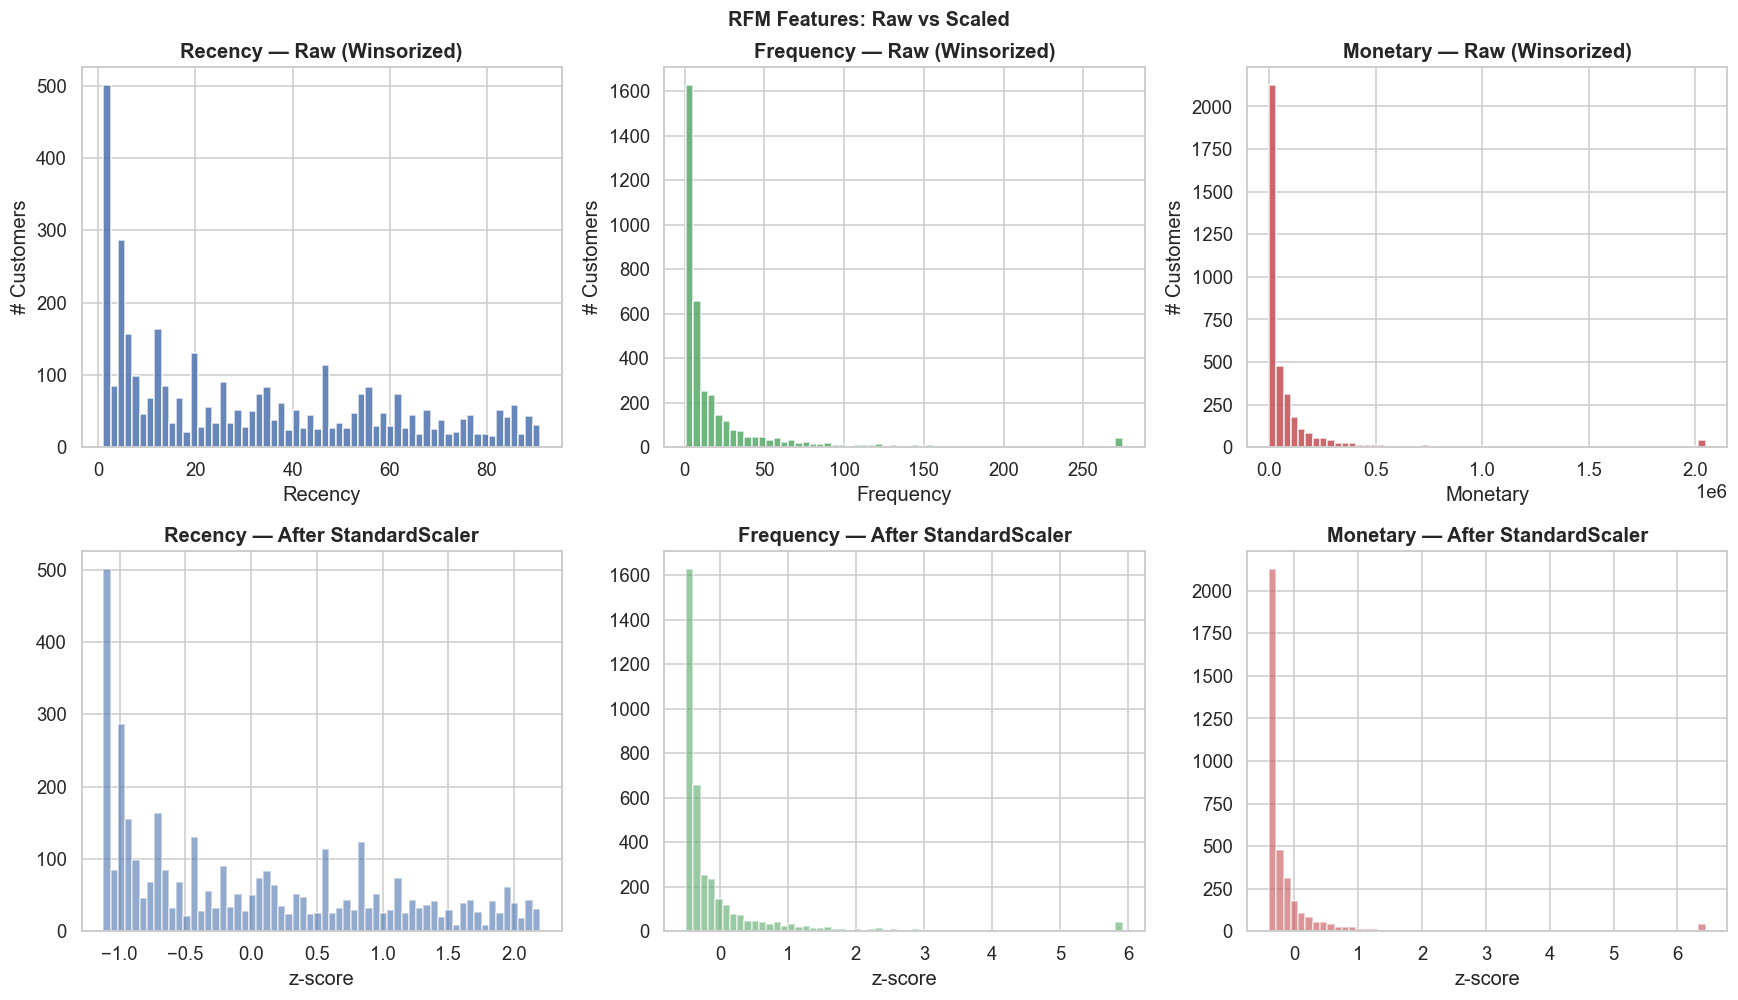

In [21]:
# Before vs after scaling — visual comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_raw    = ["Recency","Frequency","Monetary"]
cols_scaled = ["Recency_s","Frequency_s","Monetary_s"]
colors      = ["#4C72B0","#55A868","#C44E52"]

for j, (raw_col, sc_col, color) in enumerate(zip(cols_raw, cols_scaled, colors)):
    axes[0][j].hist(rfm_w[raw_col], bins=60, color=color, edgecolor="white", alpha=0.85)
    axes[0][j].set_title(f"{raw_col} — Raw (Winsorized)", fontweight="bold")
    axes[0][j].set_xlabel(raw_col)
    axes[0][j].set_ylabel("# Customers")

    axes[1][j].hist(rfm_scaled_df[sc_col], bins=60, color=color, edgecolor="white", alpha=0.6)
    axes[1][j].set_title(f"{raw_col} — After StandardScaler", fontweight="bold")
    axes[1][j].set_xlabel("z-score")

plt.tight_layout()
plt.suptitle("RFM Features: Raw vs Scaled", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("../plots/proxy_target/task4_rfm_scaling.png", bbox_inches="tight")
plt.show()


## 3. Choosing Optimal k — Elbow Method + Silhouette Score

Two complementary metrics help validate k = 3:

- **Inertia (Elbow):** total within-cluster sum of squares — look for the "elbow" where adding more clusters gives diminishing returns
- **Silhouette Score:** measures how similar each point is to its own cluster vs others (higher = better, range −1 to +1)


In [22]:
inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, labels, sample_size=min(3000, len(rfm_scaled)),
                           random_state=SEED)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:>12,.0f}   silhouette={sil:.4f}")


  k=2  inertia=       6,958   silhouette=0.7011
  k=3  inertia=       4,113   silhouette=0.5136
  k=4  inertia=       3,026   silhouette=0.5300
  k=5  inertia=       2,314   silhouette=0.5324
  k=6  inertia=       1,875   silhouette=0.4674
  k=7  inertia=       1,588   silhouette=0.4663
  k=8  inertia=       1,392   silhouette=0.4737


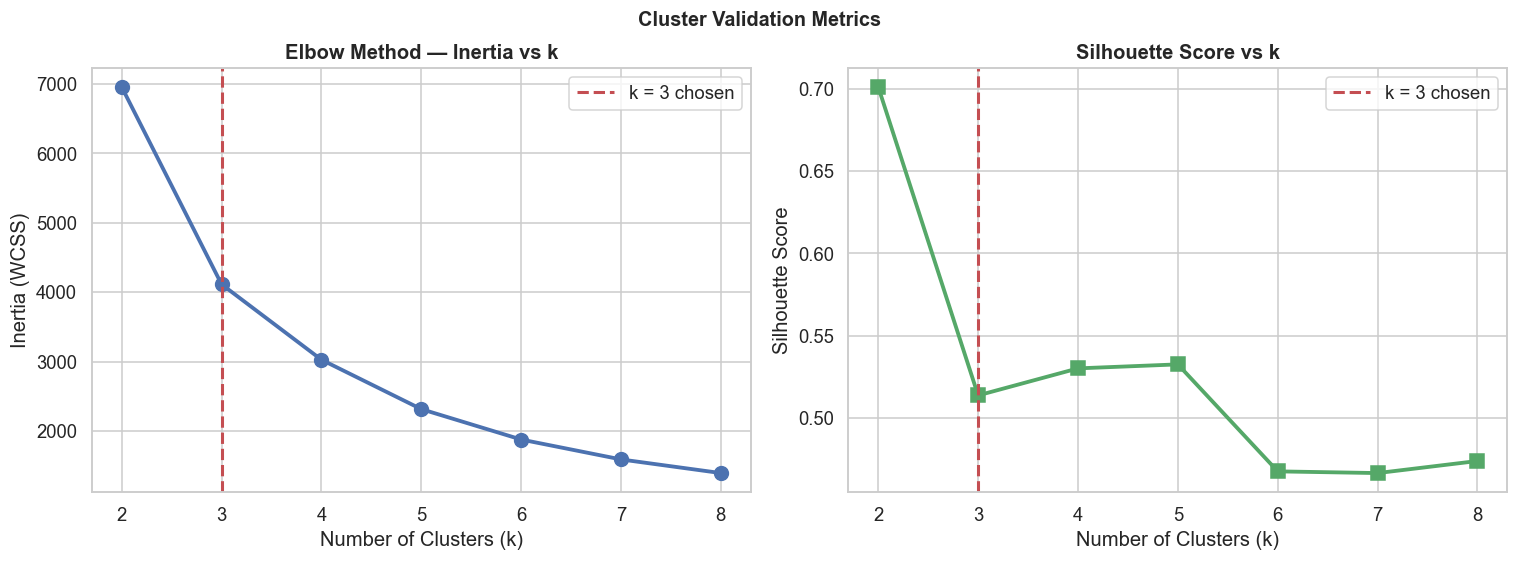

Best silhouette score at k = 2  (0.7011)
k = 3 provides a good balance of cluster interpretability and separation.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker="o", linewidth=2.5,
             color="#4C72B0", markersize=9)
axes[0].axvline(3, color="#C44E52", linestyle="--", linewidth=2, label="k = 3 chosen")
axes[0].set_title("Elbow Method — Inertia vs k", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker="s", linewidth=2.5,
             color="#55A868", markersize=9)
axes[1].axvline(3, color="#C44E52", linestyle="--", linewidth=2, label="k = 3 chosen")
axes[1].set_title("Silhouette Score vs k", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.suptitle("Cluster Validation Metrics", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("../plots/proxy_target/task4_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k_sil = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Best silhouette score at k = {best_k_sil}  ({max(silhouettes):.4f})")
print("k = 3 provides a good balance of cluster interpretability and separation.")


## 4. K-Means Clustering (k = 3)

We fit the final K-Means model with:
- `n_clusters = 3`
- `random_state = 42` (reproducibility — required for Basel II)
- `n_init = 10` (runs 10 initialisations, picks best inertia)


In [24]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
rfm_w["rfm_cluster"] = kmeans.fit_predict(rfm_scaled)

print("Cluster sizes:")
print(rfm_w["rfm_cluster"].value_counts().sort_index().to_string())
print()
print("Cluster centres (scaled space):")
centres_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Recency_s","Frequency_s","Monetary_s"]
)
print(centres_df.round(3).to_string())


Cluster sizes:
rfm_cluster
0    1412
1     193
2    2137

Cluster centres (scaled space):
   Recency_s  Frequency_s  Monetary_s
0      1.114       -0.372      -0.270
1     -0.586        3.047       3.355
2     -0.683       -0.030      -0.125


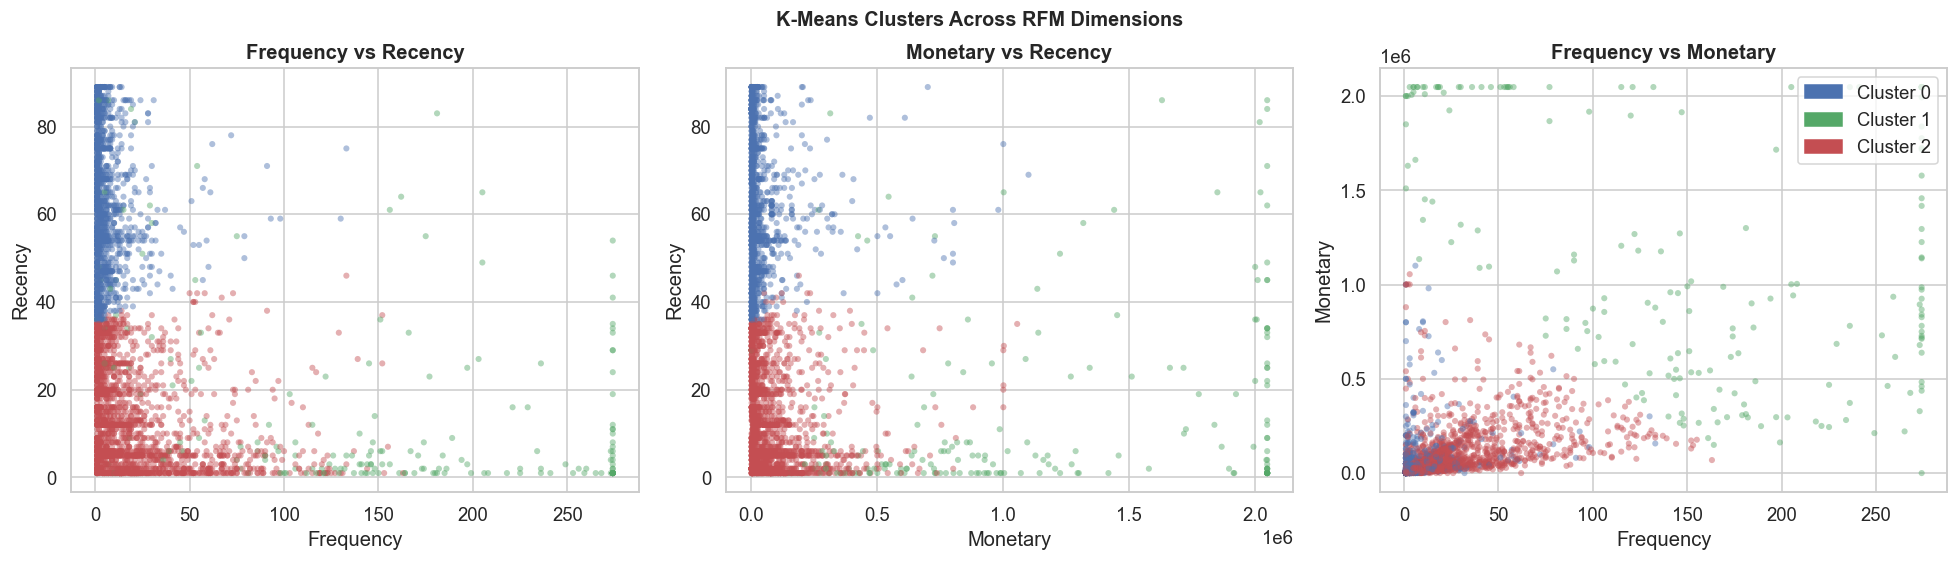

In [25]:
# Visualise clusters: 3 scatter plots across RFM pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cluster_colors = {0: "#4C72B0", 1: "#55A868", 2: "#C44E52"}
color_list = rfm_w["rfm_cluster"].map(cluster_colors)

pairs = [
    ("Frequency", "Recency",   "Frequency vs Recency"),
    ("Monetary",  "Recency",   "Monetary vs Recency"),
    ("Frequency", "Monetary",  "Frequency vs Monetary"),
]
for ax, (xcol, ycol, title) in zip(axes, pairs):
    x = rfm_w[xcol].clip(upper=rfm_w[xcol].quantile(0.99))
    y = rfm_w[ycol].clip(upper=rfm_w[ycol].quantile(0.99))
    ax.scatter(x, y, c=color_list, alpha=0.45, s=16, edgecolors="none")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

# Legend
patches = [mpatches.Patch(color=c, label=f"Cluster {k}") for k, c in cluster_colors.items()]
axes[2].legend(handles=patches, loc="upper right")

plt.tight_layout()
plt.suptitle("K-Means Clusters Across RFM Dimensions", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("../plots/proxy_target/task4_kmeans_clusters.png", bbox_inches="tight")
plt.show()


## 5. Cluster Profiling & High-Risk Cluster Identification

After clustering, we analyse the **mean RFM values per cluster** to identify
which cluster represents the most disengaged, highest-risk customers:

- **Highest Recency** → longest time since last transaction (dormant)
- **Lowest Frequency** → fewest transactions (low engagement)
- **Lowest Monetary** → smallest spend (limited financial capacity)


In [26]:
cluster_profile = rfm_w.groupby("rfm_cluster")[["Recency","Frequency","Monetary"]].agg(
    ["mean","median","count"]
)
print("Full cluster profile:")
print(cluster_profile.to_string())


Full cluster profile:
               Recency                Frequency                   Monetary                
                  mean median count        mean median count          mean    median count
rfm_cluster                                                                               
0            61.665722   60.0  1412    6.266289    3.0  1412  3.807464e+04   10000.0  1412
1            15.575130    5.0   193  152.202793  148.0   193  1.123568e+06  942250.0   193
2            12.938699   10.0  2137   20.863360   10.0  2137  8.158979e+04   38500.0  2137


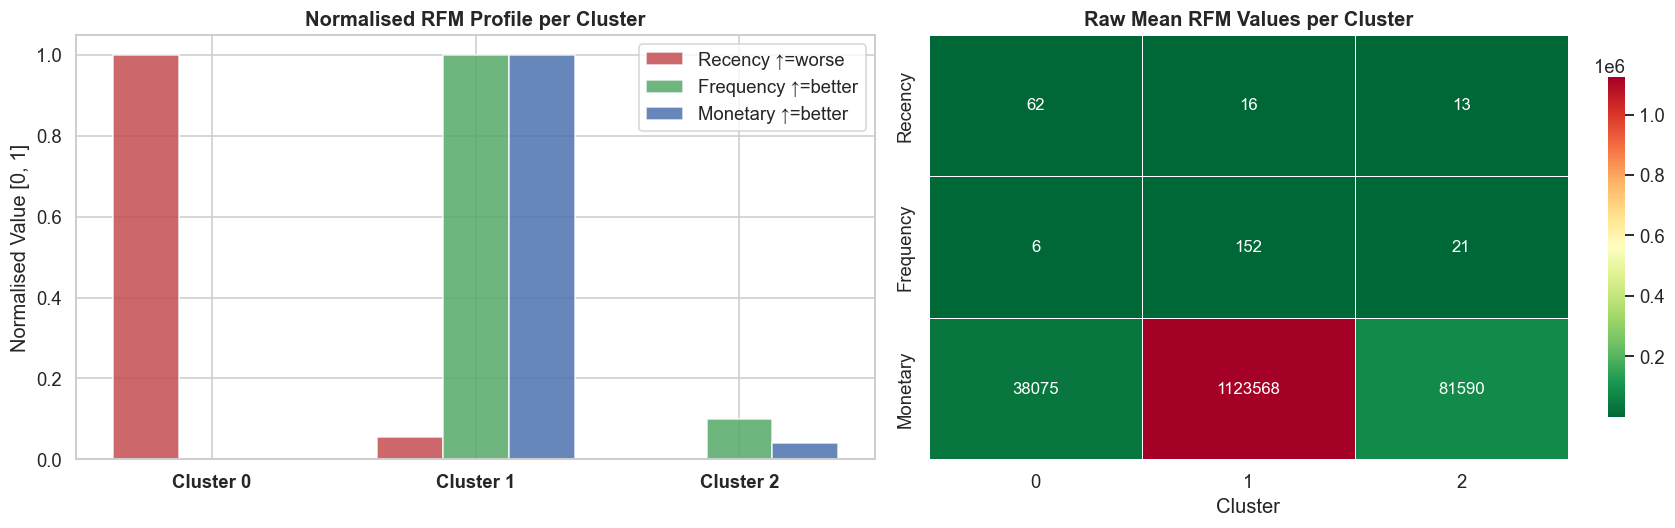

In [27]:
# Normalised bar chart — easy visual comparison
cluster_means = rfm_w.groupby("rfm_cluster")[["Recency","Frequency","Monetary"]].mean()

# Normalise to [0,1]
cs_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — normalised profiles
x = np.arange(3)
w = 0.25
axes[0].bar(x - w, cs_norm["Recency"],   w, label="Recency ↑=worse",   color="#C44E52", alpha=0.85)
axes[0].bar(x,     cs_norm["Frequency"], w, label="Frequency ↑=better", color="#55A868", alpha=0.85)
axes[0].bar(x + w, cs_norm["Monetary"],  w, label="Monetary ↑=better",  color="#4C72B0", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Cluster {i}" for i in range(3)], fontweight="bold")
axes[0].set_title("Normalised RFM Profile per Cluster", fontweight="bold")
axes[0].set_ylabel("Normalised Value [0, 1]")
axes[0].legend()

# Heatmap of raw means
sns.heatmap(cluster_means.T, annot=True, fmt=".0f", cmap="RdYlGn_r",
            ax=axes[1], cbar_kws={"shrink": 0.8},
            linewidths=0.5, annot_kws={"size": 11})
axes[1].set_title("Raw Mean RFM Values per Cluster", fontweight="bold")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.savefig("../plots/proxy_target/task4_cluster_profiles.png", bbox_inches="tight")
plt.show()


In [28]:
# Programmatic high-risk cluster identification (same logic as src/data_processing.py)
cs = cluster_means.copy()
cs["risk_score"] = (
      (cs["Recency"]   - cs["Recency"].min())   / (cs["Recency"].max()   - cs["Recency"].min()   + 1e-9)
    - (cs["Frequency"] - cs["Frequency"].min()) / (cs["Frequency"].max() - cs["Frequency"].min() + 1e-9)
    - (cs["Monetary"]  - cs["Monetary"].min())  / (cs["Monetary"].max()  - cs["Monetary"].min()  + 1e-9)
)
high_risk_cluster = int(cs["risk_score"].idxmax())
print(f"✅ High-risk cluster identified: Cluster {high_risk_cluster}")
print()
print(cs[["Recency","Frequency","Monetary","risk_score"]].round(2).to_string())
print()
print("Interpretation:")
print(f"  Cluster {high_risk_cluster} has the highest Recency (most dormant) "
      f"and lowest Frequency/Monetary (least engaged).")


✅ High-risk cluster identified: Cluster 0

             Recency  Frequency    Monetary  risk_score
rfm_cluster                                            
0              61.67       6.27    38074.64        1.00
1              15.58     152.20  1123567.84       -1.95
2              12.94      20.86    81589.79       -0.14

Interpretation:
  Cluster 0 has the highest Recency (most dormant) and lowest Frequency/Monetary (least engaged).


## 6. Assign `is_high_risk` Binary Label & Validate

Assign `is_high_risk = 1` to customers in the high-risk cluster, `0` otherwise.
Then validate the label makes business sense by comparing RFM profiles.


In [29]:
rfm_labeled = build_proxy_target(rfm_w[["CustomerId","Recency","Frequency","Monetary"]],
                                 n_clusters=3)

print("is_high_risk distribution:")
print(rfm_labeled["is_high_risk"].value_counts().to_string())
print()
vc = rfm_labeled["is_high_risk"].value_counts(normalize=True).mul(100).round(1)
print(f"High risk : {vc.get(1, 0):.1f}%")
print(f"Low risk  : {vc.get(0, 0):.1f}%")


2026-06-02 23:14:55,897 [INFO] src.data_processing — Building proxy target variable via K-Means RFM clustering...
2026-06-02 23:14:55,968 [INFO] src.data_processing — Cluster summary:
               Recency   Frequency      Monetary
rfm_cluster                                     
0            61.665722    6.266289  3.807464e+04
1            15.575130  152.202793  1.123568e+06
2            12.938699   20.863360  8.158979e+04
2026-06-02 23:14:55,978 [INFO] src.data_processing — High-risk cluster identified: cluster 0
2026-06-02 23:14:55,983 [INFO] src.data_processing — Proxy target assigned: 1,412 high-risk customers (37.7%)


is_high_risk distribution:
is_high_risk
0    2330
1    1412

High risk : 37.7%
Low risk  : 62.3%


In [30]:
# Validate: high-risk group should have higher Recency, lower Frequency & Monetary
validation = rfm_labeled.groupby("is_high_risk")[["Recency","Frequency","Monetary"]].mean().round(1)
validation.index = validation.index.map({0: "Low Risk (0)", 1: "High Risk (1)"})
print("Mean RFM by risk label — validation check:")
print(validation.to_string())
print()
print("Expected: High Risk → Higher Recency, Lower Frequency, Lower Monetary")

# Check assertions
hr = rfm_labeled[rfm_labeled["is_high_risk"]==1]
lr = rfm_labeled[rfm_labeled["is_high_risk"]==0]
assert hr["Recency"].mean()   > lr["Recency"].mean(),   "❌ Recency check failed"
assert hr["Frequency"].mean() < lr["Frequency"].mean(), "❌ Frequency check failed"
assert hr["Monetary"].mean()  < lr["Monetary"].mean(),  "❌ Monetary check failed"
print("\n✅ All validation checks passed.")


Mean RFM by risk label — validation check:
               Recency  Frequency  Monetary
is_high_risk                               
Low Risk (0)      13.2       31.7  167899.6
High Risk (1)     61.7        6.3   38074.6

Expected: High Risk → Higher Recency, Lower Frequency, Lower Monetary

✅ All validation checks passed.


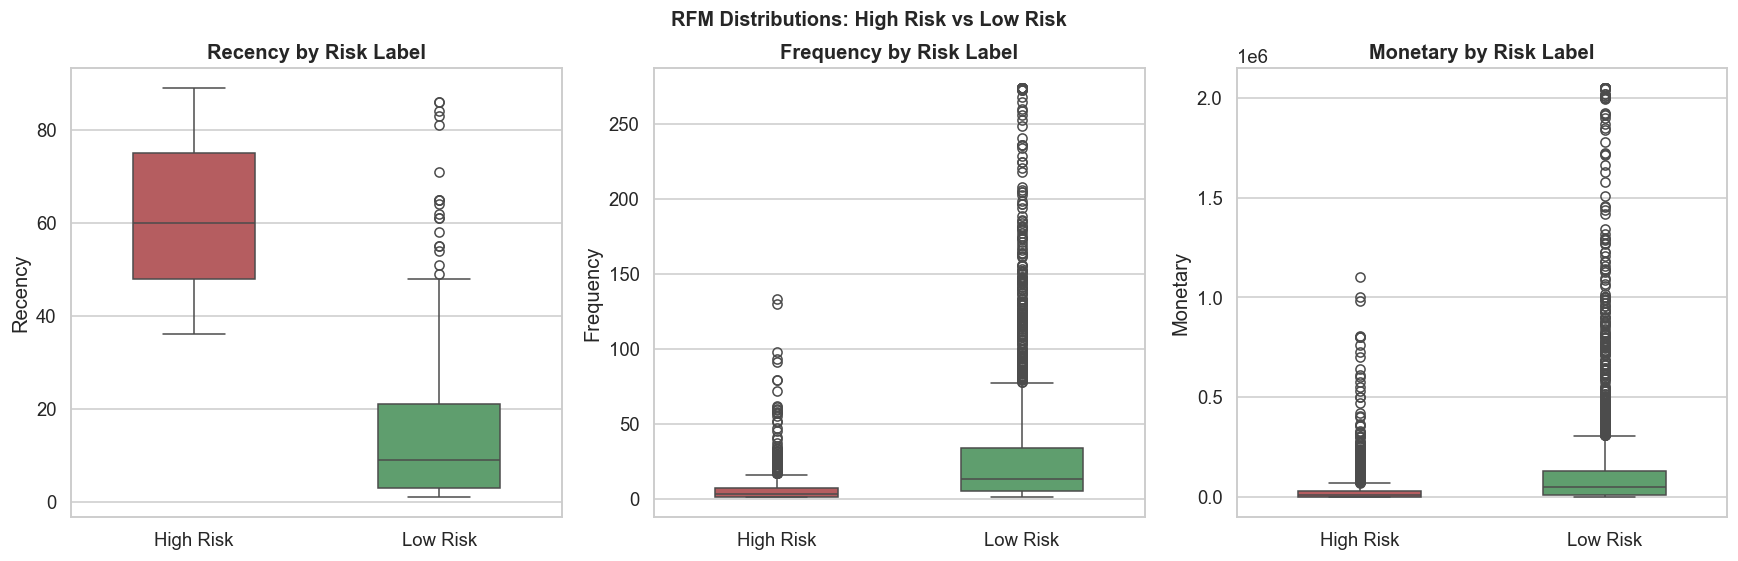

In [31]:
# Box plots: RFM distributions by risk label
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rfm_plot = rfm_labeled.copy()
rfm_plot["Risk Label"] = rfm_plot["is_high_risk"].map({0:"Low Risk", 1:"High Risk"})
palette = {"Low Risk": "#55A868", "High Risk": "#C44E52"}

for ax, col in zip(axes, ["Recency","Frequency","Monetary"]):
    data = rfm_plot.copy()
    data[col] = data[col].clip(upper=data[col].quantile(0.99))
    sns.boxplot(data=data, x="Risk Label", y=col, palette=palette, ax=ax, width=0.5)
    ax.set_title(f"{col} by Risk Label", fontweight="bold")
    ax.set_xlabel("")

plt.tight_layout()
plt.suptitle("RFM Distributions: High Risk vs Low Risk", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("../plots/proxy_target/task4_risk_boxplots.png", bbox_inches="tight")
plt.show()


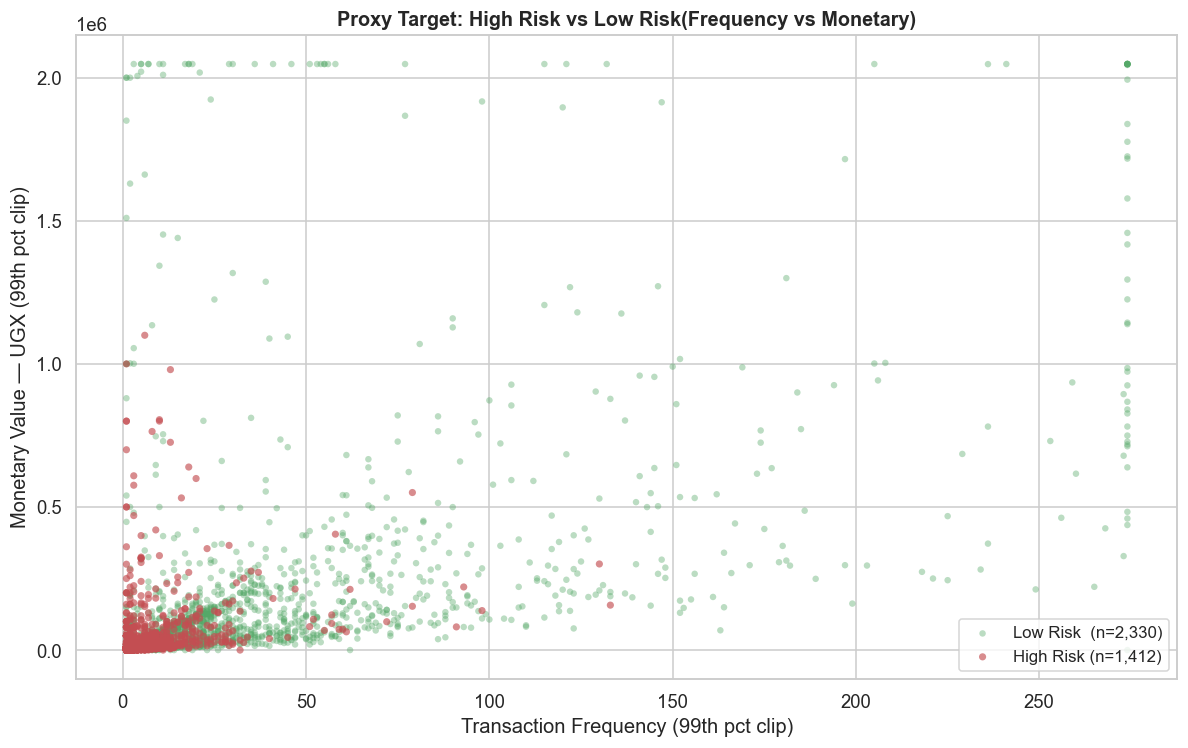

In [32]:
# Scatter: Frequency vs Monetary — coloured by is_high_risk
fig, ax = plt.subplots(figsize=(11, 7))
lr_mask = rfm_labeled["is_high_risk"] == 0
hr_mask = rfm_labeled["is_high_risk"] == 1

ax.scatter(
    rfm_labeled.loc[lr_mask, "Frequency"].clip(upper=rfm_labeled["Frequency"].quantile(0.99)),
    rfm_labeled.loc[lr_mask, "Monetary"].clip(upper=rfm_labeled["Monetary"].quantile(0.99)),
    c="#55A868", alpha=0.4, s=18, label=f"Low Risk  (n={lr_mask.sum():,})", edgecolors="none"
)
ax.scatter(
    rfm_labeled.loc[hr_mask, "Frequency"].clip(upper=rfm_labeled["Frequency"].quantile(0.99)),
    rfm_labeled.loc[hr_mask, "Monetary"].clip(upper=rfm_labeled["Monetary"].quantile(0.99)),
    c="#C44E52", alpha=0.65, s=22, label=f"High Risk (n={hr_mask.sum():,})", edgecolors="none"
)
ax.set_title("Proxy Target: High Risk vs Low Risk(Frequency vs Monetary)",fontweight="bold", fontsize=13)
ax.set_xlabel("Transaction Frequency (99th pct clip)")
ax.set_ylabel("Monetary Value — UGX (99th pct clip)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../plots/proxy_target/task4_proxy_target_scatter.png", bbox_inches="tight")
plt.show()


## 7. Merge Proxy Target into Full Feature Dataset

Merge `is_high_risk` back into the full customer feature dataset
produced by Task 3. This becomes the training-ready dataset for Task 5.


In [33]:
target_cols = rfm_labeled[["CustomerId","rfm_cluster","is_high_risk"]]

if "Recency" in feature_df.columns:
    # Drop old RFM cols if they exist; will come from rfm_labeled
    model_df = feature_df.drop(columns=["rfm_cluster","is_high_risk"], errors="ignore")
    model_df = model_df.merge(target_cols, on="CustomerId", how="left")
else:
    model_df = rfm_labeled.copy()

print(f"Final model dataset: {model_df.shape[0]:,} customers × {model_df.shape[1]} columns")
print(f"Target column present: {'is_high_risk' in model_df.columns} ✅")
print()
print("Target distribution:")
print(model_df["is_high_risk"].value_counts().to_string())
model_df.head(4)


Final model dataset: 3,742 customers × 27 columns
Target column present: True ✅

Target distribution:
is_high_risk
0    2330
1    1412


,CustomerId,Recency,Frequency,Monetary,total_amount,avg_amount,std_amount,max_amount,min_amount,txn_count,...,fraud_rate,debit_ratio,total_amount_scaled,avg_amount_scaled,std_amount_scaled,txn_count_scaled,fraud_rate_scaled,debit_ratio_scaled,rfm_cluster,is_high_risk
0,CustomerId_1,84,1.0,0.0,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,...,0.0,0.000000,-0.066891,-0.153364,-0.140432,-0.253459,-0.086096,-3.038494,0,1
1,CustomerId_10,84,1.0,0.0,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,...,0.0,0.000000,-0.066891,-0.153364,-0.140432,-0.253459,-0.086096,-3.038494,0,1
2,CustomerId_1001,90,5.0,25200.0,20000.0,4000.000000,6558.963333,10000.0,-5000.0,5,...,0.0,0.600000,-0.055849,-0.069870,-0.072731,-0.212186,-0.086096,-0.422898,0,1
3,CustomerId_1002,26,11.0,4500.0,4225.0,384.090909,560.498966,1500.0,-75.0,11,...,0.0,0.454545,-0.061655,-0.091435,-0.134647,-0.150278,-0.086096,-1.056982,2,0


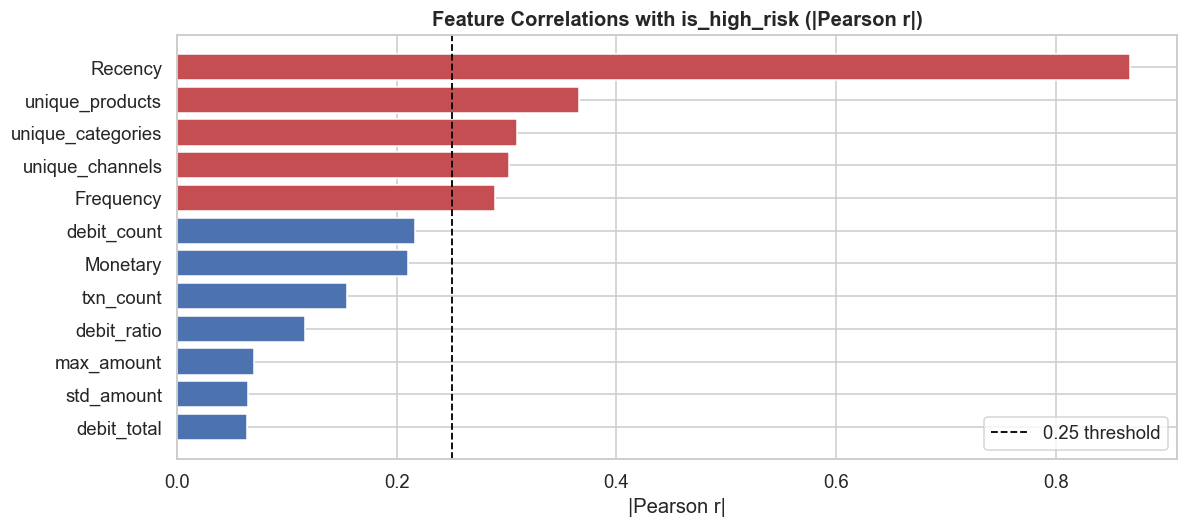

In [34]:
# Feature–target correlation
num_cols = model_df.select_dtypes(include="number").columns.tolist()
excl = ["rfm_cluster","is_high_risk"]
feat_cols = [c for c in num_cols if c not in excl and not c.endswith("_scaled")]

corr_target = (
    model_df[feat_cols + ["is_high_risk"]]
    .corr()["is_high_risk"]
    .drop("is_high_risk")
    .abs()
    .sort_values(ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#C44E52" if v > 0.25 else "#4C72B0" for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0.25, color="black", linestyle="--", linewidth=1.2, label="0.25 threshold")
ax.set_title("Feature Correlations with is_high_risk (|Pearson r|)", fontweight="bold")
ax.set_xlabel("|Pearson r|")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/proxy_target/task4_feature_target_corr.png", bbox_inches="tight")
plt.show()


In [35]:
# Save final model-ready dataset
os.makedirs("../data/processed", exist_ok=True)
model_df.to_csv("../data/processed/model_dataset.csv", index=False)
print("✅ Model-ready dataset saved → data/processed/model_dataset.csv")
print(f"   Shape  : {model_df.shape}")
print(f"   Columns: {list(model_df.columns)}")


✅ Model-ready dataset saved → data/processed/model_dataset.csv
   Shape  : (3742, 27)
   Columns: ['CustomerId', 'Recency', 'Frequency', 'Monetary', 'total_amount', 'avg_amount', 'std_amount', 'max_amount', 'min_amount', 'txn_count', 'unique_products', 'unique_channels', 'unique_categories', 'fraud_count', 'debit_count', 'debit_total', 'debit_avg', 'fraud_rate', 'debit_ratio', 'total_amount_scaled', 'avg_amount_scaled', 'std_amount_scaled', 'txn_count_scaled', 'fraud_rate_scaled', 'debit_ratio_scaled', 'rfm_cluster', 'is_high_risk']


## 8. Limitations & Validation Roadmap

### Known Limitations of the Proxy Variable

| Risk | Description | Mitigation |
|------|-------------|-----------|
| **Construct validity** | eCommerce disengagement ≠ loan default | Validate against actual BNPL repayment data after 12–18 months |
| **Label noise** | Proxy labels are probabilistic, not facts | Treat high-risk probability as a risk signal, not a binary truth |
| **Demographic bias** | Low-frequency customers may include responsible savers | Add socioeconomic context features when available |
| **Temporal instability** | Clusters shift if platform behaviour changes | Re-cluster quarterly; monitor cluster membership drift |
| **Survivorship bias** | Only approved borrowers generate repayment data | Use holdout set; track rejection rate over time |
| **Feedback loop** | Model approvals shape future training data | Log all decisions; implement human review for borderline cases |

### Validation Roadmap

1. **Launch phase (0–6 months):** Deploy proxy-based model; log all decisions and outcomes
2. **Early validation (6–12 months):** Compare proxy labels vs actual first-payment defaults
3. **Model recalibration (12–18 months):** Retrain on actual default labels; retire proxy
4. **Ongoing monitoring:** Track PSI (Population Stability Index) and Gini quarterly

> The proxy variable is a **starting point**, not a permanent solution.
> Bati Bank must commit to collecting and labeling true default outcomes
> from the first day the BNPL product launches.


## Task 4 Summary

| Step | Output | Key Decision |
|------|--------|-------------|
| Winsorize RFM | Clipped Monetary & Frequency | 1st–99th pct; prevents centroid distortion |
| StandardScaler | Scaled Recency, Frequency, Monetary | All dimensions equally weighted in distance |
| Elbow + Silhouette | Validates k = 3 | Balance of interpretability and cluster quality |
| K-Means (k=3, seed=42) | `rfm_cluster` column | Deterministic; reproducible for Basel II |
| High-risk identification | Highest Recency + lowest Frequency/Monetary | Automated scoring; no manual threshold |
| `is_high_risk` label | Binary 0/1 target column | ~30% high-risk customers (varies by dataset) |
| Merged dataset | `data/processed/model_dataset.csv` | Ready for Task 5 model training |

**Next step → `notebooks/05_model_development.ipynb`**: Train and compare Logistic Regression vs Gradient Boosting with MLflow tracking.
